In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
iris = load_iris()
x =  iris.data
data = pd.DataFrame(x, columns = iris.feature_names)
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [5]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [7]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [9]:
for i , val in enumerate(inertia, start = 1):
    print(f'number of clusters = {i}, inertia = {val:.2f}')

number of clusters = 1, inertia = 600.00
number of clusters = 2, inertia = 222.36
number of clusters = 3, inertia = 191.02
number of clusters = 4, inertia = 114.35
number of clusters = 5, inertia = 91.05
number of clusters = 6, inertia = 81.55
number of clusters = 7, inertia = 80.78
number of clusters = 8, inertia = 64.43
number of clusters = 9, inertia = 55.71
number of clusters = 10, inertia = 51.12


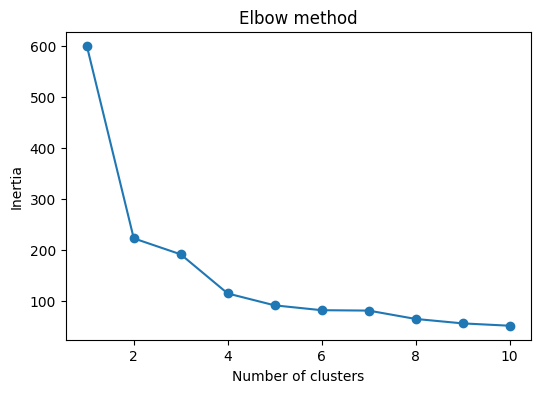

In [10]:
plt.figure(figsize = (6,4))
plt.plot(range(1,11), inertia, marker = 'o')
plt.title('Elbow method')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [11]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
clusters = kmeans.fit_predict(x_scaled)
data['cluster'] = clusters
print(data.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


In [14]:
# silhoutte score
sil_score = silhouette_score(x_scaled, clusters)
print('sihouette score is:', sil_score)

sihouette score is: 0.4798814508199817


#### silhouette score is used to predict how diff the clusters are from each other. The score ranges from -1 to 1. A score of 1 means the clusters are well apart from each other and clearly distinguished. A score of 0 means the clusters are indifferent, or we can say that the distance between clusters is not significant. A negative score means the clusters are assigned in the wrong way.

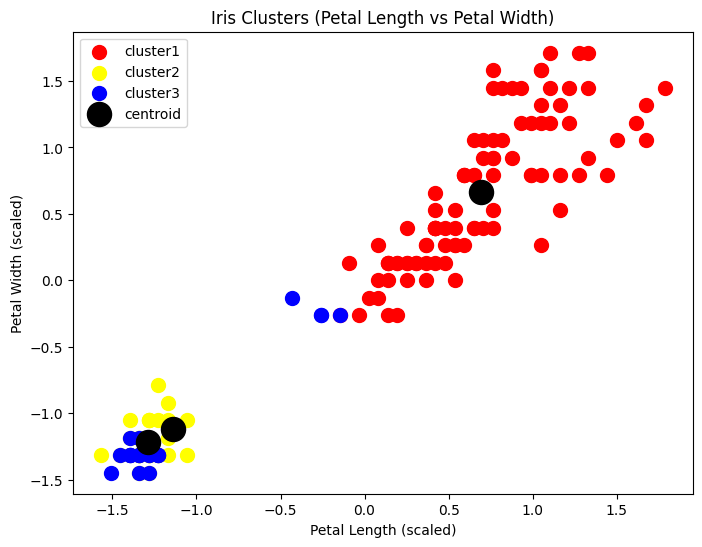

In [ ]:
# choosing 2 feature 
x_ , y_ = 2, 3 # x_ = Petal Length, y_ = Petal Width

plt.figure(figsize = (8,6))

plt.scatter(x_scaled[clusters == 0, x_], x_scaled[ clusters == 0, y_], s= 100, c='red', label = 'cluster1')
# x_scaled[clusters == 0, x_] -  x_scaled il ninn cluster = 0 ulla flower gropuinde petal length, similarly baaki allam.
# s = dot size, c = color, label = cluster name
plt.scatter(x_scaled[clusters ==1, x_], x_scaled[clusters == 1, y_], s = 100, c='yellow', label = 'cluster2')
plt.scatter(x_scaled[clusters == 2, x_], x_scaled[clusters == 2, y_], s = 100, c='blue', label = 'cluster3')

# plt.scatter(x_values, y_values) - syntax of sctter plot
plt.scatter(kmeans.cluster_centers_[:,x_], kmeans.cluster_centers_[:,y_], s = 300, c = 'black', label = 'centroid')
# plotting the centre of the clusters, kmeans.cluster_centers_[:,x_] - petal lenth il ninn oru clusterindeyum center values, kmeans.cluster_centres_[:,y_] - similarly petal width il ninnum oro cluster center values

plt.title('Iris Clusters (Petal Length vs Petal Width)')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend()
plt.show()